# Estudo prático sobre Redes Neurais Recorrentes

## Objetivo
Geração de texto autoregressivo

## Tipo de tokenização
Subword-level (BPE)

## Dataset
Wikipedia (no-pic-pt)

## Idioma
Português

## Tamanho das observações
Parágrafos entre 150 e 200 caracteres.

## Arquitetura utilizada
LSTM (Long Short-term Memory)

In [1]:
import torch
import torch.nn as nn
from tokenizers import Tokenizer
from typing import List, Tuple
import pandas as pd
from lstm import LSTM, LSTMBidirectional, LSTMAttention
import json
from tqdm import tqdm
from utils import Dataset
from inference import test_step, evaluate_models, predicting, test_step_attention
import os
from pprint import pprint

In [2]:
models_retry = [LSTM, LSTMBidirectional, LSTMAttention]

In [3]:
model_names = os.listdir('runs/')
modelos = {}
configs = {}
for model_name in model_names:
    with open(f"models/{model_name}/config.json", "r", encoding="utf-8") as f:
        config: dict = json.load(f)
    for M in models_retry:
        try:
            model = M(
                config['emb_size'],
                config['vocab_size'],
                config['encoder_num_layers'],
                config['encoder_hidden_size'],
                config['encoder_dropout'],
                config['decoder_num_layers'],
                config['decoder_hidden_size'],
                config['decoder_dropout']
            ).to('cpu')
            model.load_state_dict(torch.load(f"models/{model_name}/model.pt", map_location='cpu'))
            break
        except Exception as e:
            continue
    

    tokenizer = Tokenizer.from_file(f"artifacts/bpe_{config['vocab_size']}.json")
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    config['parameters'] = trainable_params
    config.pop('device')
    config.pop('exp_name')
    modelos[model_name] = (model, tokenizer)
    configs[model_name] = config

1536 768
1536 768
1024 512


## Hiperpârametros de treinamento
Foram feitos 4 tokenizadores de tamanhos diversos de vocabulário (5k, 10k, 25k e 50k).
O Learning rate foi feito sem nenhum tipo de scheduler, fixado em 1e-4.

In [4]:
df = pd.DataFrame.from_dict(configs).T
df

,vocab_size,max_len,emb_size,encoder_hidden_size,encoder_num_layers,encoder_dropout,decoder_hidden_size,decoder_num_layers,decoder_dropout,batch_size,eval_batch_size,accum_steps,log_steps,eval_steps,learning_rate,epochs,parameters,warmup_steps
v1,25000.0,512.0,128.0,256.0,2.0,0.0,256.0,2.0,0.0,32.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,11468200.0,NaN
v2,25000.0,512.0,256.0,384.0,2.0,0.0,384.0,2.0,0.0,32.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,20362664.0,NaN
v3_bidirectional,25000.0,512.0,256.0,384.0,2.0,0.0,384.0,2.0,0.0,32.0,32.0,1.0,500.0,2000.0,0.0001,1000.0,26071976.0,NaN
v4_bidirectional_warmup,25000.0,512.0,256.0,384.0,2.0,0.0,384.0,2.0,0.0,32.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,26071976.0,2000.0
v5_attention,25000.0,512.0,128.0,256.0,2.0,0.0,256.0,2.0,0.0,64.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,20757160.0,2000.0


### Curva de treino e validação

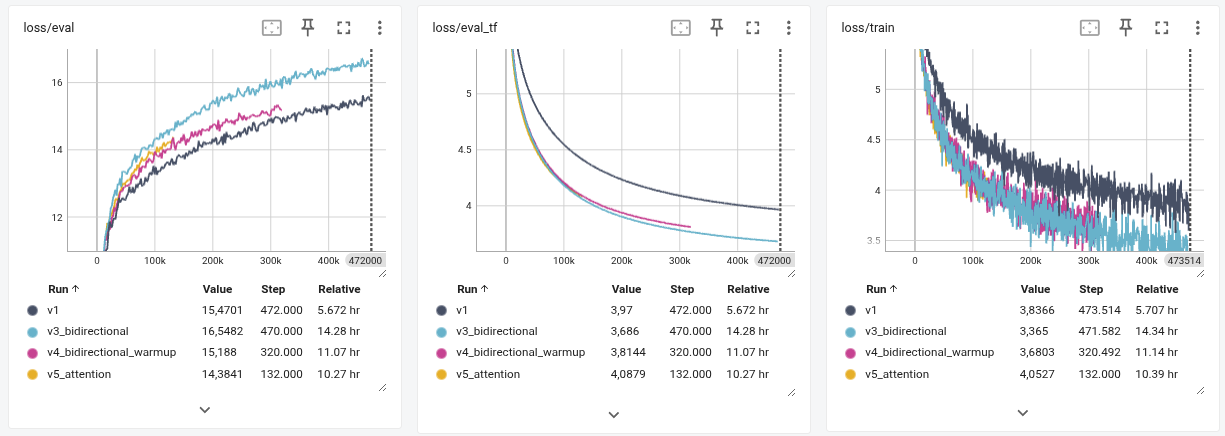

## 📈 Avaliação dos Gradientes

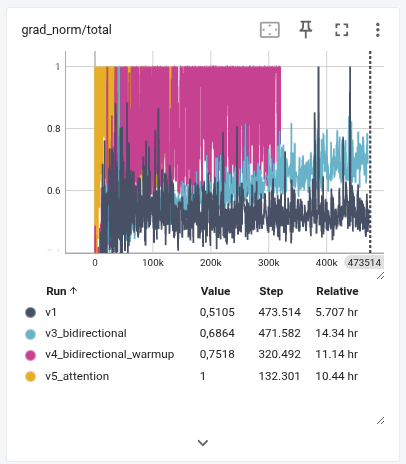

In [5]:
config_test = {
    'batch_size': 96,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'vocab_size': 25000
}

step_info = {'test_accum_steps': 0, 'test_loss_sum':0, 'test_loss_tf_sum': 0}

In [6]:
df_test = pd.read_parquet('data/test_wiki_cleaned_cutted.pq')

In [7]:
df_test_sample = df_test.sample(128)

In [8]:
df_results = pd.DataFrame()
modelo, tok = modelos['v5_attention']

modelo = modelo.to(config_test['device'])

dataset_test = Dataset(
    df_test.tokens.values.tolist(),
    max_len=512
)

dataloader_test = torch.utils.data.DataLoader(
    dataset=dataset_test, 
    batch_size=config_test['batch_size'],
    shuffle=True
)

loss, loss_tf, phrases_pred, phrases_input, tokens_pred_total, tokens_input_total, phrases_output, tokens_output_total = test_step_attention(config_test, step_info, modelo, dataloader_test, tok.get_vocab_size(), tok)
df_results = pd.concat([df_results,pd.DataFrame({
    'modelo': [model_name]*len(phrases_input), 
    'frase_input_original': phrases_input, 
    'frase_output_original': phrases_output,
    'frase_preditada': phrases_pred,
    'tokens_input_originais': tokens_input_total,
    'tokens_output_originais': tokens_output_total,
    'tokens_preditados': tokens_pred_total,
    'loss': [loss]*len(phrases_input),
    'loss_tf': [loss_tf]*len(phrases_input),
    })])

Testing: 100%|██████████| 857/857 [02:57<00:00,  4.83it/s]


In [9]:
modelos.pop('v5_attention')

(LSTMAttention(
   (embedding): Embedding(25000, 128)
   (LSTMEncoder): LSTM(128, 256, num_layers=2, batch_first=True, bidirectional=True)
   (LSTMDecoder): LSTM(384, 256, num_layers=2, batch_first=True)
   (encoded_proj): Linear(in_features=512, out_features=256, bias=True)
   (proj_h): Linear(in_features=1024, out_features=512, bias=True)
   (proj_c): Linear(in_features=1024, out_features=512, bias=True)
   (out_layer): Linear(in_features=512, out_features=25000, bias=True)
 ),
 Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":1, "content":"[BOS]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":2, "content":"[EOS]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":3, "content":"[UNK]", "single_word":False, "lstrip":False, "rstrip":False, "normaliz

In [10]:
for model_name, item in modelos.items():
    modelo, tok = item

    modelo = modelo.to(config_test['device'])

    dataset_test = Dataset(
        df_test.tokens.values.tolist(),
        max_len=512
    )

    dataloader_test = torch.utils.data.DataLoader(
        dataset=dataset_test, 
        batch_size=config_test['batch_size'],
        shuffle=True
    )

    loss, loss_tf, phrases_pred, phrases_input, tokens_pred_total, tokens_input_total, phrases_output, tokens_output_total = test_step(config_test, step_info, modelo, dataloader_test, tok.get_vocab_size(), tok)
    df_results = pd.concat([df_results,pd.DataFrame({
        'modelo': [model_name]*len(phrases_input), 
        'frase_input_original': phrases_input, 
        'frase_output_original': phrases_output,
        'frase_preditada': phrases_pred,
        'tokens_input_originais': tokens_input_total,
        'tokens_output_originais': tokens_output_total,
        'tokens_preditados': tokens_pred_total,
        'loss': [loss]*len(phrases_input),
        'loss_tf': [loss_tf]*len(phrases_input),
        })])

Testing: 100%|██████████| 857/857 [02:19<00:00,  6.16it/s]


In [11]:
df_results = df_results.reset_index(drop=True)

In [12]:
df_results

,modelo,frase_input_original,frase_output_original,frase_preditada,tokens_input_originais,tokens_output_originais,tokens_preditados,loss,loss_tf
0,v5_attention,"Helga Liné nascida Helga Lina Stern Berlim, 1...",de Adolfo Coelho. A família passou a viver na...,"uma família de judeus, e foi um dos mais impo...","[1, 3949, 469, 279, 6231, 10032, 3949, 469, 27...","[160, 18872, 11222, 8, 2, 1, 198, 1183, 1496, ...","[248, 1183, 160, 4867, 6, 158, 284, 240, 320, ...",14.368042,4.072022
1,v5_attention,"Manuel Rodrigues Gameiro Pessoa Portugal, c. ...","hipoteca de rendas da alfândega, junto com Fe...","teca, que se tornaram populares e, em seguida,...","[1, 3503, 6079, 5878, 472, 11732, 1551, 6, 164...","[9711, 16174, 160, 211, 2507, 208, 327, 54, 39...","[16174, 6, 210, 205, 4521, 5233, 158, 6, 201, ...",14.368042,4.072022
2,v5_attention,A lista dos participantes de todas as edições...,inados em um hotel permanecendo até adentrar a...,de cada grupo para cada rodada do júri. A vot...,"[1, 198, 2415, 320, 6102, 160, 1533, 283, 5777...","[4161, 201, 240, 10439, 12549, 578, 600, 280, ...","[160, 1080, 1010, 243, 1080, 5653, 200, 13366,...",14.368042,4.072022
3,v5_attention,Matricaria é um género de plantas com flor pe...,culo é 2-3 vezes mais alto do que largo. O pap...,"é muito pequeno, com uma única semente, com u...","[1, 2662, 1013, 703, 273, 240, 6189, 160, 3807...","[766, 273, 246, 7, 13, 1173, 347, 2939, 200, 2...","[273, 854, 3642, 6, 197, 248, 2397, 20973, 6, ...",14.368042,4.072022
4,v5_attention,Gestão da informação GI diz respeito a um cic...,", o que torna relevante e útil para a pessoa q...",o que é um dos principais objetivos de serviç...,"[1, 17217, 208, 4680, 291, 31, 1556, 4270, 159...","[6, 176, 210, 3248, 12904, 158, 9429, 243, 159...","[176, 210, 273, 240, 320, 1623, 7171, 160, 281...",14.368042,4.072022
...,...,...,...,...,...,...,...,...,...
410985,v4_bidirectional_warmup,"Em matemática, um paraboloide é uma superfíci...",é aberta para cima e a parábola no plano y0 a...,de um ponto de fusão. A função de um vetor é ...,"[1, 355, 7179, 6, 240, 243, 1115, 63, 790, 273...","[273, 6568, 243, 6523, 158, 159, 359, 2412, 72...","[160, 240, 2095, 160, 6572, 8, 2, 1, 198, 2690...",15.178182,19.101266
410986,v4_bidirectional_warmup,Os bantus ou bantos constituem um grupo etno ...,". C. , começaram a expandir seu território na ...","C. , os povos indígenas da Ásia Central, que ...","[1, 513, 549, 165, 289, 307, 549, 873, 9397, 2...","[8, 2, 1, 213, 8, 2, 1, 122, 6, 3395, 159, 126...","[2, 1, 213, 8, 2, 1, 122, 6, 276, 4749, 5245, ...",15.178182,19.101266
410987,v4_bidirectional_warmup,"a 2,7 km/h/s frenagem de emergência: 3. 6 km/...",tium THSRC e o Chungwa High Speed Rail Consort...,um e a tecnologia de transporte de dados de ca...,"[1, 159, 246, 6, 17, 1162, 9, 56, 9, 67, 958, ...","[1153, 411, 270, 30, 41, 16254, 158, 176, 647,...","[411, 158, 159, 4470, 160, 3966, 160, 2267, 16...",15.178182,19.101266
410988,v4_bidirectional_warmup,A TVA sigla para Televisão Abril foi uma oper...,Machline e lança 5 canais: Showtime TVA Filme...,"line, com a marca de 1 milhão de dólares, e a ...","[1, 198, 2148, 23, 13073, 243, 16974, 5428, 28...","[5652, 4649, 158, 1790, 632, 6598, 20, 6909, 1...","[4649, 6, 197, 159, 2396, 160, 222, 5666, 160,...",15.178182,19.101266


In [16]:
indexes_samples = df_results.sample(20).index
for i in indexes_samples:
    pprint({
        'model': df_results.loc[i, 'modelo'],
        'input': df_results.loc[i, 'frase_input_original'],
        'output': df_results.loc[i, 'frase_preditada']
    })

    print()

{'input': ' Virgílio Gomes Delgado Teixeira Santa Maria Maior, Funchal, 26 de '
          'outubro de 1917 Funchal, 5 de dezembro de 2010, conhecido como '
          'Virgílio Teixeira, foi um ator português que atuou durante as '
          'décadas de 40, 50 e 60 do século XX, sendo um dos mais reconhecidos '
          'galãs do cinema português. Participou em 92 produções, 150 '
          'programas de televisão e duas peças de teatro em Portugal, Espanha '
          'e nos Estados Unidos. Nasceu a 26 de outubro de 1917, no n. 9 da '
          'Rua Latino Coelho, freguesia de Santa Maria Maior, no Funchal. Era '
          'filho de Gastão Gomes Teixeira, comerciante, então de 24 anos, '
          'natural da freguesia da Sé, no Funchal, e de Celestina Clarisse '
          'Delgado Teixeira, então de 24 anos, natural de Georgetown. A 7 de '
          'abril de 1938, pouco antes de completar 21 anos idade legal da '
          'maioridade, foi emancipado a seu pedido, para poder casar-s